# 1. Explore pre-trained word vectors. Explore word relationships using vector arithmetic. Perform arithmetic operations and analyze results.

In [4]:
# !pip install gensim

from gensim.downloader import load

print ('Loading pre-trained Glove model (50 dimensions)...')

model = load ("glove-wiki-gigaword-50")

def ewr () :
    result = model.most_similar (
        positive = ['king', 'woman'],
        negative = ['man'],
        topn = 1
    )

    print ('\nKing - Man + Woman = ?', result [0][0])
    print ('Similarity: ', result [0][1])

    result = model.most_similar (
        positive = ['paris', 'italy'],
        negative = ['france'],
        topn = 1
    )

    print ('\nParis - France + Italy = ?', result [0][0])
    print ('Similairity: ', result [0][1])

    result = model.most_similar (
        positive = ['programming'],
        topn = 5
    )

    print ("\nTop 5 words similar to 'programming'")

    for word, similarity in result : print (word, similarity)

ewr ()


Loading pre-trained Glove model (50 dimensions)...

King - Man + Woman = ? queen
Similarity:  0.8523604273796082

Paris - France + Italy = ? rome
Similairity:  0.8465589284896851

Top 5 words similar to 'programming'
network 0.7707955241203308
interactive 0.7613597512245178
format 0.7584694623947144
channels 0.753067672252655
networks 0.752894937992096


# 2. Use dimensionality reduction (e.g., PCA or t-SNE) to visualize word embeddings for Q 1. Select 10 words from a specific domain (e.g., sports, technology) and visualize their embeddings. Analyze clusters and relationships. Generate contextually rich outputs using embeddings. Write a program to generate 5 semantically similar words for a given input.


Loading pre-trained Glove Model (50 dimensions)...
2D Visualization of Word Embeddings saved as 'wordembeddings.png'



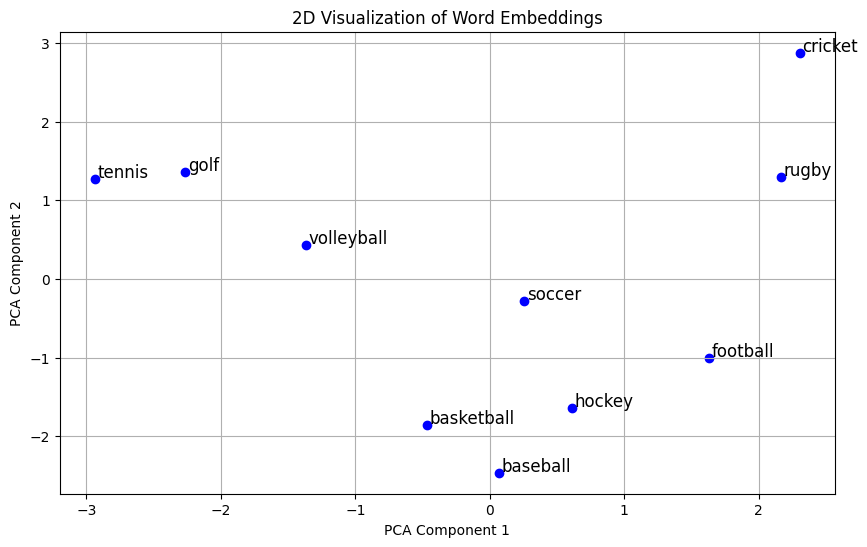


Top 5 words similar to 'programming': 
network (0.770796)
interactive (0.761360)
format (0.758469)
channels (0.753068)
networks (0.752895)


In [14]:
# if gensim is not installed, use the below line and run, wait about a few minutes for it to install
# !pip install gensim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.downloader import load

def reduce_dimensions (embeddings) :
    pca = PCA (n_components = 2)
    reduced_embeddings = pca.fit_transform (embeddings)

    return reduced_embeddings

def visualize_embeddings (words, reduced_embeddings) :
    plt.figure (figsize = (10, 6))
 
    for i, word in enumerate (words) :
        x, y = reduced_embeddings [i]
 
        plt.scatter (x, y, color = 'blue', marker = 'o')
        plt.text (x + 0.02, y + 0.02, word, fontsize = 12)
        
    plt.title ('2D Visualization of Word Embeddings')

    plt.xlabel ('PCA Component 1')
    plt.ylabel ('PCA Component 2')

    plt.grid (True)

    plt.savefig ('word-embeddings.png', dpi = 300, bbox_inches = 'tight')

    print ("2D Visualization of Word Embeddings saved as 'wordembeddings.png'\n")

    plt.show ()
 
def get_similar_words (word, model) :
    print (f"\nTop 5 words similar to '{word}': ")
    similar_words = model.most_similar (word, topn = 5)

    for similar_word, similarity in similar_words :
        print (f"{similar_word} ({similarity:.6f})")

print ('\nLoading pre-trained Glove Model (50 dimensions)...')

model = load ("glove-wiki-gigaword-50")
words = ['football', 'basketball', 'soccer', 'tennis', 'cricket', 'hockey', 'baseball', 'golf', 'volleyball', 'rugby']

embeddings = [model [word] for word in words]
reduced_embeddings = reduce_dimensions (embeddings)
visualize_embeddings (words, reduced_embeddings)

get_similar_words ('programming', model)


# 3. Train a custom Word2Vec model on a small dataset. Train embeddings on a domain-specific corpus (e.g., legal, medical) and analyze how embeddings capture domain-specific semantics.

Enter a word:  patient



Words similar to 'patient': 
1. invasive (Similarity:  0.9524)
2. the (Similarity:  0.9078)
3. antibiotics (Similarity:  0.8369)
4. published (Similarity:  0.6993)
5. abnormalities (Similarity:  0.5822)
Word Embeddings (PCA Projection) saved as 'word2vec.png'



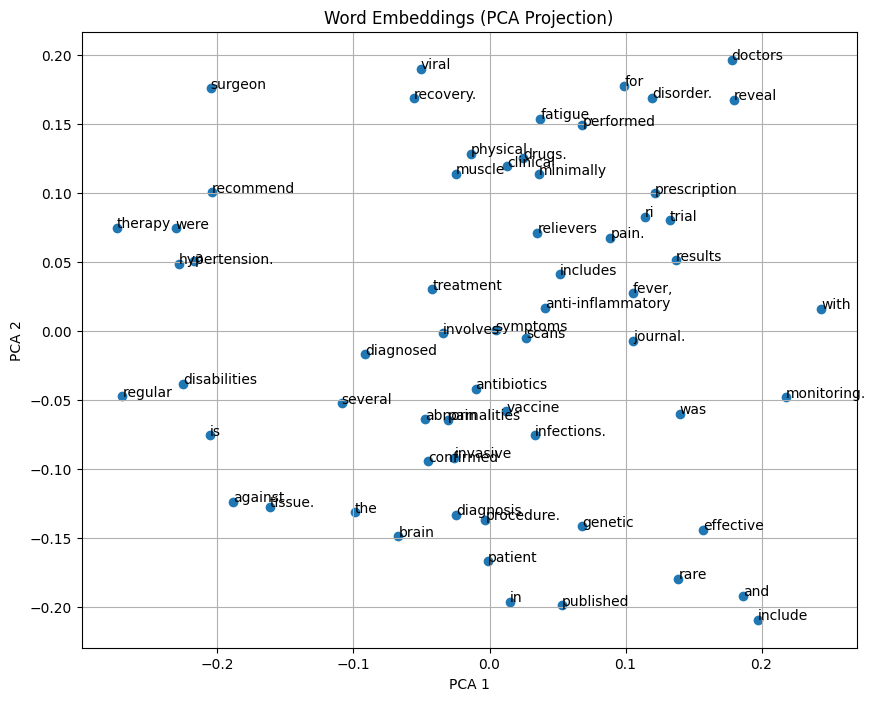

In [3]:
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

corpus = [
    "The patient was diagnosed with disabilities and hypertension.",
    "RI scans reveal abnormalities in the brain tissue.",
    "The treatment involves antibiotics and regular monitoring.",
    "Symptoms include fever, fatigue, and muscle pain.",
    "The vaccine is effective against several viral infections.",
    "Doctors recommend physical therapy for recovery.",
    "The clinical trial results were published in the journal.",
    "The surgeon performed a minimally invasive procedure.",
    "The prescription includes pain relievers and anti-inflammatory drugs.",
    "The diagnosis confirmed a rare genetic disorder."]

tokenized_corpus = [sentence.lower ().split ()    for sentence in corpus]

model = Word2Vec (sentences = tokenized_corpus, vector_size = 5, window = 2, min_count = 1, epochs = 5)
word = input ('Enter a word: ').lower ()

if word in model.wv :
    similar = model.wv.most_similar (word, topn = 5)

    print (f"\nWords similar to '{word}': ")

    for i, (w, score) in enumerate (similar, 1) : print (f"{i}. {w} (Similarity: {score: .4f})")
else : print ('Word not found in vocabulary!')

words = list (model.wv.index_to_key)
word_vectors = model.wv [words]

pca = PCA (n_components = 2)

result = pca.fit_transform (word_vectors)

plt.figure (figsize = (10, 8))
plt.scatter (result [:, 0], result [:, 1]) 

for i, word in enumerate (words) :
    plt.annotate (word, xy = (result [i, 0], result [i, 1]))

plt.title ('Word Embeddings (PCA Projection)')

plt.xlabel ('PCA 1')
plt.ylabel ('PCA 2')

plt.grid (True)

plt.savefig ('word2vec.png', dpi = 300, bbox_inches = 'tight')

print ("Word Embeddings (PCA Projection) saved as 'word2vec.png'\n")

plt.show ()


# 4. Use word embeddings to improve prompts for Generative AI model. Retrieve similar words using word embeddings. Use the similar words to enrich a GenAI prompt. Use the AI model to generate responses for the original and enriched prompts. Compare the outputs in terms of detail and relevance.

In [3]:
!pip install cohere gensim

import cohere
import gensim.downloader as api

co = cohere.Client ("MUOuOWxVgm8vXm5TIHw8RbjEJZZUmDK7OUxRUIcq")

print ("Loading word embeddings...")

model = api.load("glove-wiki-gigaword-100")

print ("Model loaded successfully.")

prompt = "write an essay on natural disaster"

def get_first_enriched_prompt (prompt, topn = 3) : 
    for word in prompt.split () :
        try : 
            similar_words = model.most_similar (word.strip ('.,!?').lower (), topn = topn)

            for sim, _ in similar_words :
                enriched = prompt.replace (word, sim)
                return enriched

        except : continue

    return None

def get_response (text) :
    try :
        return co.chat (model = "command-r", message = text).text.strip ()

    except Exception as e : return f"Error: (e)"

print (f"\nOriginal Prompt: \n{prompt})\nResponse:\n{get_response (prompt)}")

enriched_prompt = get_first_enriched_prompt (prompt)

if enriched_prompt:
    print (f"\nEnriched Prompt: \n{enriched_prompt})\nResponse: \n{get_response (enriched_prompt)}")

else : print ("\nNo enriched prompt could be generated!")


'D:\Python_3.13\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.


Loading word embeddings...
Model loaded successfully.

Original Prompt: 
write an essay on natural disaster)
Response:
Error: (e)

Enriched Prompt: 
writing an essay on natural disaster)
Response: 
Error: (e)


# 5. Use word embeddings to create meaningful sentences for creative tasks. Retrieve similar words for a seed word. Create a sentence or story using these words as a starting point. Write a program that: Takes a seed word. Generates similar words. Constructs a short paragraph using these words.

In [3]:
from gensim.downloader import load
import random

print ('Loading pre-trained Glove model (50 dimensions)...')

model = load ("glove-wiki-gigaword-50")

print ('Model loaded successfully.\n')

def create_paragraph (iw, sws) :
    paragraph = 'The topic of (iw) is fascinating, often linked to terms like '
    random.shuffle (sws)

    for word in sws : paragraph += str (word) + ", "

    paragraph = paragraph.rstrip (", ") + "."

    return paragraph

iw =  'hacking'
sws = model.most_similar (iw, topn = 5)
words = [word for word, s in sws]

paragraph = create_paragraph (iw, words)

print (paragraph)


Loading pre-trained Glove model (50 dimensions)...
Model loaded successfully.

The topic of (iw) is fascinating, often linked to terms like hacked, malicious, hacker, snooping, hackers.


# 6. Use a pre-trained Hugging Face model to analyze sentiment in text. Assume a real-world application, Load the sentiment analysis pipeline. Analyze the sentiment by giving sentences to input.

In [2]:
# install transformers if not already installed
!pip install transformers torch

from transformers import pipeline

sentiment_analyzer = pipeline ('sentiment-analysis')

while True :
    user_input = input ("\nEnter a sentence (or type 'exit' or 'quit'): ")

    if user_input.lower () == "exit" : print ('Goodbye!')
        break

    if not user_input.strip () : print ('Please enter a non-empty sentence.')
        continue

    result = sentiment_analyzer (user_input) [0]

    print (f"\nLabel: {result ['label']}")
    print (f"Confidence: {result ['score']: .4f}")


   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
   -- --------------

D:\Python_3.13\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
D:\Python_3.13\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more d


Enter a sentence (or type 'exit' or 'quit'):  she is good girl



Label: POSITIVE
Confidence:  0.9999



Enter a sentence (or type 'exit' or 'quit'):  exit


Goodbye!


# 7. Summarize long texts using a pre-trained summarization model using Hugging face model. Load the summarization pipeline. Take a passage as input and obtain the summarized text.

In [9]:
from transformers import pipeline

summarizer = pipeline ('summarization',
                      model = "facebook/bart-large-cnn")

text = input ('Enter text to summarize: \n')

if len (text.split ()) < 30 : print ('Text is too short to summarize!')
else : 
    summary = summarizer (text,
                            max_length = 50, min_length = 30,
                            do_sample = False
                         ) [0] ['summary_text']
    print ('\nSummary: ', summary)


KeyError: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"